In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso, LassoCV
from sklearn.preprocessing import StandardScaler

In [2]:
df=pd.read_csv("/Users/melodyqian/Documents/GitHub/FindMyNuclearWaste/data/MLDataset.csv")
dummydf = pd.get_dummies(df, columns=['Urban_Rural'], drop_first=True)
dummydf= dummydf[dummydf['house_value_median']>0]
dummydf= dummydf[dummydf['household_income_median']>0]
dummydf=dummydf[dummydf['county_data']==0]
collinear= ['nonhispanic_percent', 'femalepercent','missing_race','county_data', 'index']
dummydf = dummydf.drop(columns=collinear, axis=1)
print(dummydf)


     occupied_percent  house_value_median  household_income_median  \
0               0.700            210500.0                  67250.0   
1               0.790            256100.0                  80750.0   
2               0.870            307200.0                  68269.0   
3          146750.000            472400.0                  72182.0   
4               0.970            260900.0                  79601.0   
..                ...                 ...                      ...   
114             0.828             33009.0                  64145.0   
115             0.808            162734.0                  84948.0   
116             0.576             28110.0                  37813.0   
117             0.905             29950.0                  47837.0   
118             0.731             50297.0                  88802.0   

     age_median  malepercent  hispanic_percent  white_percent  black_percent  \
0          55.1        0.520             0.010          0.980          0.000   

In [ ]:
#plt.figure(figsize = (10, 10))
#sns.heatmap(dummydf.corr(), annot = True)

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

In [7]:
y = dummydf['site']
X = dummydf.drop('site', axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:

lasso = Lasso(alpha=1.0)
lasso.fit(X_train, y_train)


Lasso()

In [9]:
train_score_ls = lasso.score(X_train, y_train)
test_score_ls = lasso.score(X_test, y_test)

print("The train score for ls model is {}".format(train_score_ls))
print("The test score for ls model is {}".format(test_score_ls))

The train score for ls model is 0.3042788462684194
The test score for ls model is 0.3889628575110573


In [12]:
lasso_cv = LassoCV(alphas=[0.001, 0.01, 0.1, 1.0, 10.0], cv=5)
lasso_cv.fit(X_train, y_train)

LassoCV(alphas=[0.001, 0.01, 0.1, 1.0, 10.0], cv=5)

In [13]:
print(f"Best alpha: {lasso_cv.alpha_}")
print(f"Train score: {lasso_cv.score(X_train, y_train)}")
print(f"Test score: {lasso_cv.score(X_test, y_test)}")

Best alpha: 0.001
Train score: 0.4791765937932235
Test score: 0.5254016953982834


In [14]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)
print(f"LR train: {lr.score(X_train, y_train)}")
print(f"LR test: {lr.score(X_test, y_test)}")

LR train: 0.5352310123348631
LR test: 0.398699386561436


In [15]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
print(f"RF train: {rf.score(X_train, y_train)}")
print(f"RF test: {rf.score(X_test, y_test)}")

RF train: 0.9737165371809101
RF test: 0.9927216666666666


                    Feature  Importance
1        house_value_median    0.762642
2   household_income_median    0.091707
4               malepercent    0.072418
9           pacific_percent    0.019997
0          occupied_percent    0.017313
6             white_percent    0.010828
11    median_family_percent    0.009532
8             asian_percent    0.007937
7             black_percent    0.002888
5          hispanic_percent    0.002428
3                age_median    0.001913
12        Urban_Rural_Rural    0.000325
10           native_percent    0.000070
13        Urban_Rural_Urban    0.000000


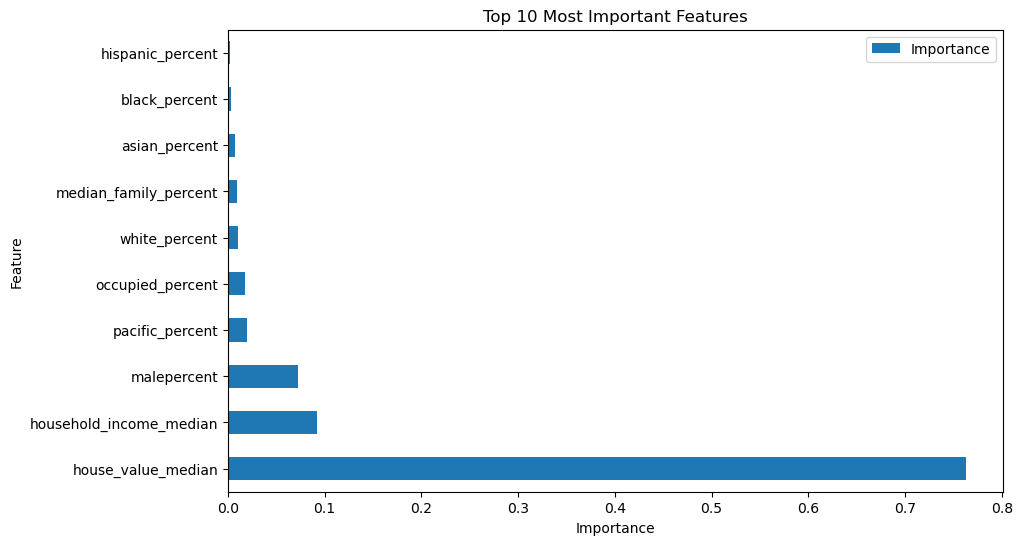

In [17]:
# See which features the model relies on most
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance.head(20))

# Plot it
import matplotlib.pyplot as plt
feature_importance.head(10).plot(x='Feature', y='Importance', kind='barh', figsize=(10,6))
plt.xlabel('Importance')
plt.title('Top 10 Most Important Features')
plt.show()
